In [3]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Dataset Information

print("Shape of Dataset:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Shape of Dataset: (9994, 21)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
# Check Duplicate Rows

duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [6]:
# Convert Date Columns

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [7]:
# Create New Date Features

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Day'] = df['Order Date'].dt.day
df['Weekday'] = df['Order Date'].dt.day_name()

df[['Order Date', 'Year', 'Month', 'Day', 'Weekday']].head()

,Order Date,Year,Month,Day,Weekday
0,2016-11-08,2016,November,8,Tuesday
1,2016-11-08,2016,November,8,Tuesday
2,2016-06-12,2016,June,12,Sunday
3,2015-10-11,2015,October,11,Sunday
4,2015-10-11,2015,October,11,Sunday


C:\Users\Admin\AppData\Local\Temp\ipykernel_3208\2200315856.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_category.values,


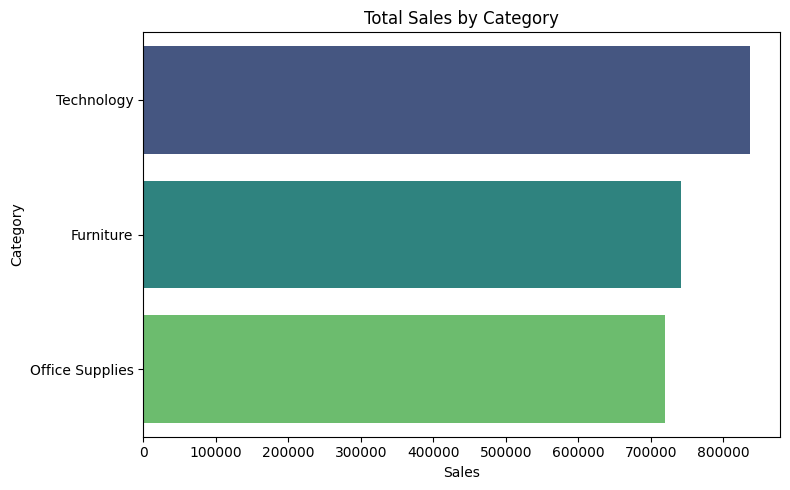

In [8]:
# Sales by Category

sales_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=sales_category.values,
            y=sales_category.index,
            palette="viridis")

plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig("sales_by_category.png")
plt.show()

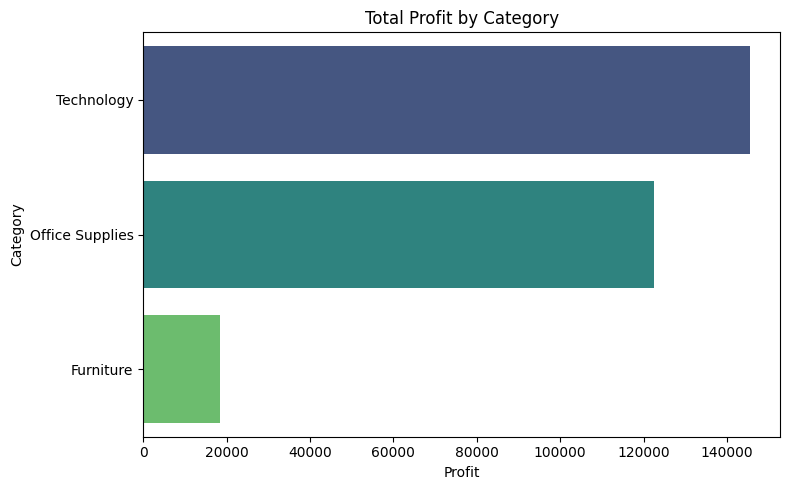

In [9]:
# Profit by Category

profit_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    x=profit_category.values,
    y=profit_category.index,
    hue=profit_category.index,
    palette="viridis",
    legend=False
)

plt.title("Total Profit by Category")
plt.xlabel("Profit")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig("profit_by_category.png")
plt.show()

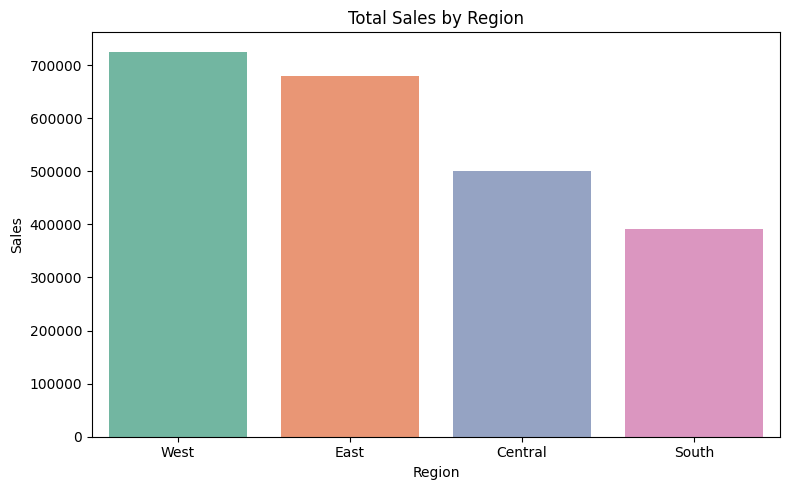

In [10]:
# Sales by Region

sales_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    x=sales_region.index,
    y=sales_region.values,
    hue=sales_region.index,
    palette="Set2",
    legend=False
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("sales_by_region.png")
plt.show()

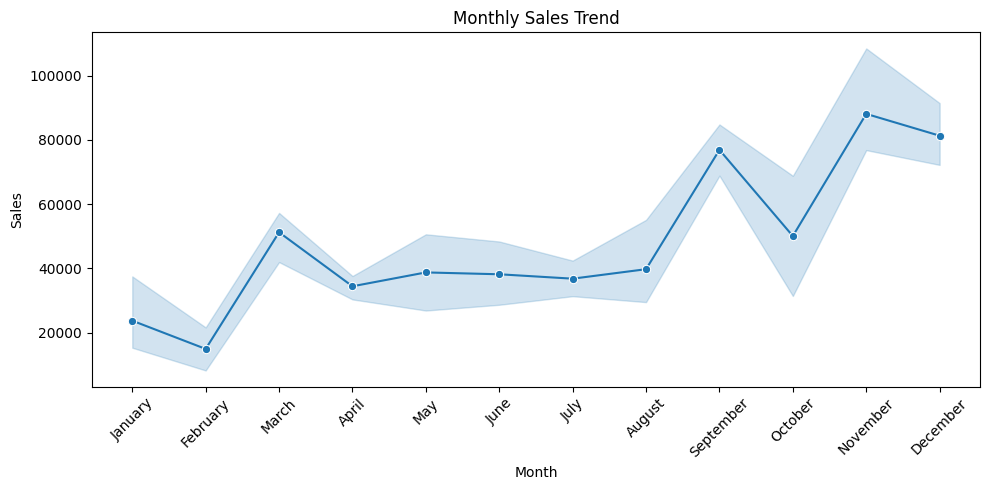

In [11]:
# Monthly Sales Trend

monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Sales',
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("monthly_sales_trend.png")
plt.show()

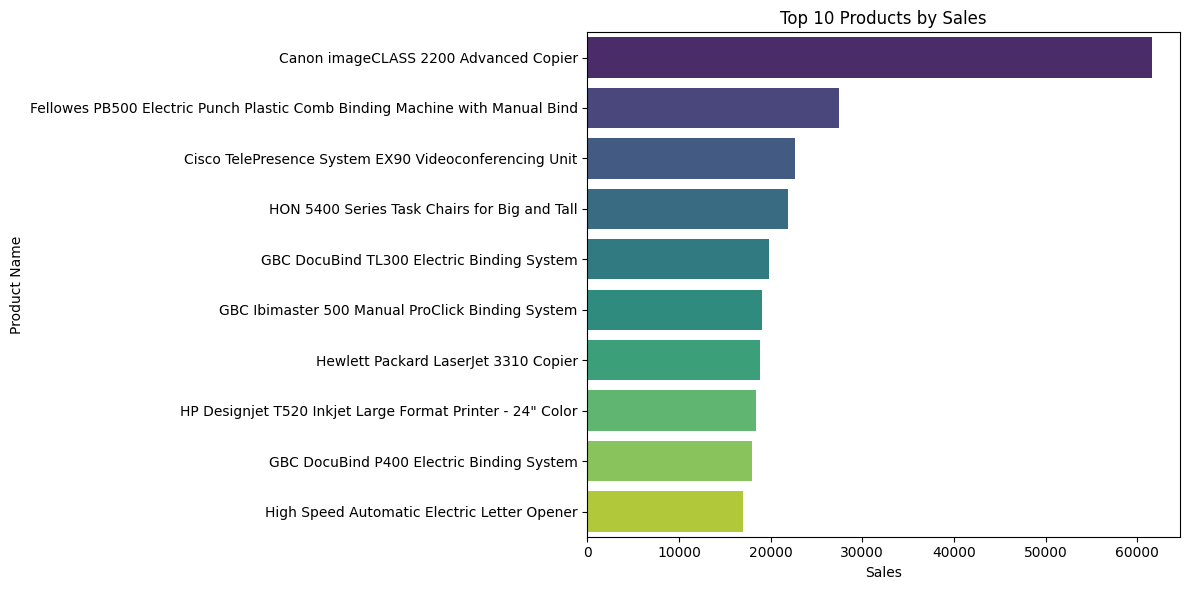

In [12]:
# Top 10 Products by Sales

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")

plt.tight_layout()

plt.savefig("top10_products.png")
plt.show()